Import libraries

In [ ]:
# Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, IsolationForest

In [ ]:
data = pd.read_csv("transaction_anomalies_dataset.csv")
data.head()

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,Friday,6:00,36,Male,1436074,Savings
1,TX1,1013.952065,4,1020.210306,7,22,Friday,1:00,41,Female,627069,Savings
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings
4,TX4,998.777241,1,1007.111026,7,7,Friday,8:00,56,Female,649457,Savings


Looking for null values in dataset

In [ ]:
data.isnull().sum()

,0
Transaction_ID,0
Transaction_Amount,0
Transaction_Volume,0
Average_Transaction_Amount,0
Frequency_of_Transactions,0
Time_Since_Last_Transaction,0
Day_of_Week,0
Time_of_Day,0
Age,0
Gender,0


In [ ]:
# Dataset shape
data.shape

# Column names and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               1000 non-null   object 
 1   Transaction_Amount           1000 non-null   float64
 2   Transaction_Volume           1000 non-null   int64  
 3   Average_Transaction_Amount   1000 non-null   float64
 4   Frequency_of_Transactions    1000 non-null   int64  
 5   Time_Since_Last_Transaction  1000 non-null   int64  
 6   Day_of_Week                  1000 non-null   object 
 7   Time_of_Day                  1000 non-null   object 
 8   Age                          1000 non-null   int64  
 9   Gender                       1000 non-null   object 
 10  Income                       1000 non-null   int64  
 11  Account_Type                 1000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


Dataset Shape & Structure

Histogram: Overall Distribution of Transaction Amount

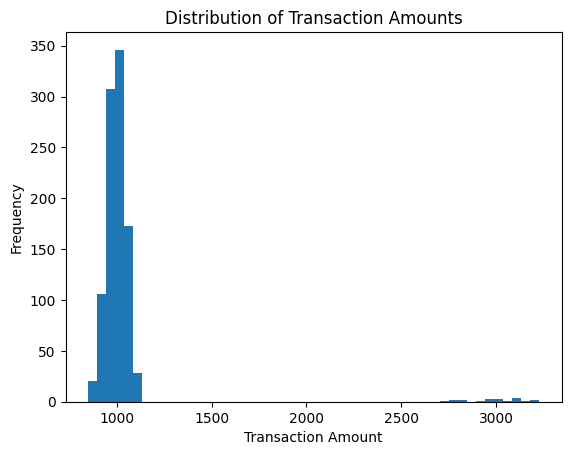

In [ ]:
plt.figure()
plt.hist(data["Transaction_Amount"], bins=50)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

Check For The Account Types

In [ ]:
data["Account_Type"].value_counts()

,count
Account_Type,
Current,516
Savings,484


Transaction Amount by Account Type (Boxplot)

<Figure size 640x480 with 0 Axes>

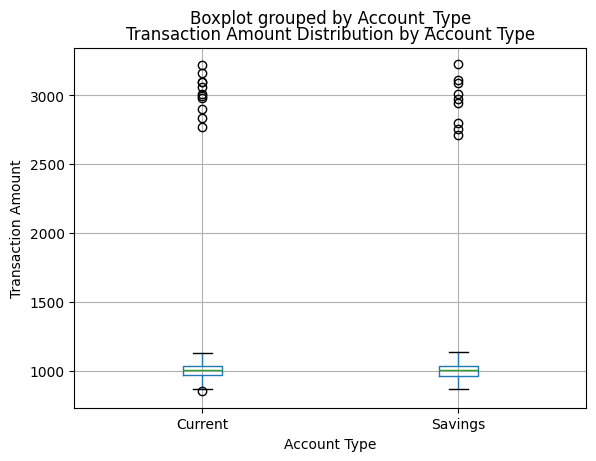

In [ ]:
plt.figure()
data.boxplot(column="Transaction_Amount", by="Account_Type")
plt.title("Transaction Amount Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Transaction Amount")
plt.show()

The histogram shows that most transaction amounts are concentrated within a narrow mid-range, representing typical customer behavior, while a small number of very high-value transactions appear far from the main cluster. This right-skewed distribution indicates the presence of potential outliers and justifies the use of anomaly detection techniques. The observed spread of values also highlights the importance of feature scaling during preprocessing



```
# This is formatted as code
```

Time Since Last Transaction vs Transaction Amount

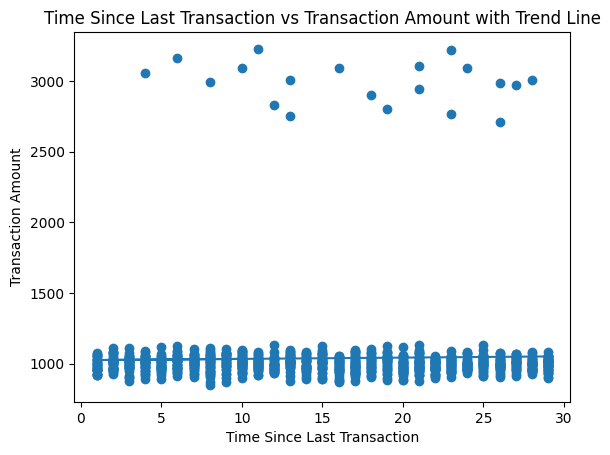

In [ ]:
# x and y
x = data['Time_Since_Last_Transaction']
y = data['Transaction_Amount']

# Plotting a scatter plot
plt.scatter(x, y)

# The Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labeling
plt.xlabel('Time Since Last Transaction')
plt.ylabel('Transaction Amount')
plt.title('Time Since Last Transaction vs Transaction Amount with Trend Line')

plt.show()

In [ ]:
# Select numeric columns
featurescale = [
    'Transaction_Amount',
    'Average_Transaction_Amount',
    'Frequency_of_Transactions',
    'Time_Since_Last_Transaction',
    'Age',
    'Income',
    'Transaction_Volume'
]

X = data[featurescale]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[-0.04687724, -0.16718985, -0.01838278,  1.63442333, -0.33598683,
         1.56800704,  0.45044692],
       [-0.08527588,  0.94693949, -1.1967659 ,  0.79680979,  0.02598993,
        -0.7756884 ,  1.34775153],
       [-0.23697021, -0.54242526, -1.66811915, -0.39978098,  1.47389696,
        -0.31459163, -1.34416231],
       [ 0.00952498, -1.51100781,  0.92432372,  1.51476426,  1.47389696,
        -0.79897747, -0.4468577 ],
       [-0.13881427,  0.31173095, -1.1967659 , -0.99807636,  1.1119202 ,
        -0.71083015, -1.34416231]])

No missing values detected → skipping imputation step

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)
print("Total samples:", X_scaled.shape)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# Since the dataset does not contain labeled fraud instances,
# the problem was treated as an unsupervised anomaly detection task.
# A random 80:20 train–test split was performed to learn normal transaction
# patterns from the training data and evaluate anomaly detection performance on unseen data.

Total samples: (1000, 7)
Training samples: (800, 7)
Testing samples: (200, 7)


In [ ]:
# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume ~5% anomalies
    random_state=42
)

iso_forest.fit(X_scaled)

# Predict anomalies
data['IF_Anomaly'] = iso_forest.predict(X_scaled)

# Convert: -1 = anomaly, 1 = normal
data['IF_Anomaly'] = data['IF_Anomaly'].map({1: 0, -1: 1})

# Count anomalies
data['IF_Anomaly'].value_counts()

,count
IF_Anomaly,
0,950
1,50


In [ ]:
# Calculate the number of anomalies
num_anomalies = data['IF_Anomaly'].sum()

# Calculate the total number of instances in the dataset
total_instances = data.shape[0]

# Calculate the ratio of anomalies
anomaly_ratio = num_anomalies / total_instances
print(anomaly_ratio)

0.05


In [ ]:
# Isolation forest
relevant_features = ['Transaction_Amount', 'Average_Transaction_Amount', 'Frequency_of_Transactions']

# Split data into features (X) and target variable (y)
X = data[relevant_features]
y = data['IF_Anomaly']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train the Isolation Forest model
model = IsolationForest(contamination = 0.02, random_state = 42)
model.fit(X_train)

IsolationForest(contamination=0.02, random_state=42)

In [ ]:
# Predict anomalies on the test set
y_pred = model.predict(X_test)

# Convert predictions to binary values (0: normal, 1: anomaly)
y_pred_binary = [1 if pred == -1 else 0 for pred in y_pred]

# Evaluate the model's performance
report = classification_report(y_test, y_pred_binary, target_names=['Normal', 'Anomaly'])
print(report)

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       193
     Anomaly       1.00      0.57      0.73         7

    accuracy                           0.98       200
   macro avg       0.99      0.79      0.86       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
data['Anomaly_Score'] = iso_forest.decision_function(X_scaled)

In [ ]:
data.sort_values('Anomaly_Score').head(10)

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,IF_Anomaly,Anomaly_Score
724,TX724,2903.890238,4,1073.154036,10,18,Thursday,19:00,47,Female,905556,Current,1,-0.087501
422,TX422,3218.959781,1,965.597949,15,23,Sunday,9:00,27,Female,1002495,Current,1,-0.085701
878,TX878,2982.897583,3,972.379854,5,26,Saturday,19:00,47,Male,551666,Current,1,-0.081096
484,TX484,3166.250653,4,1011.935656,18,6,Monday,14:00,20,Female,745093,Current,1,-0.075064
570,TX570,2973.267078,2,972.715045,5,27,Monday,8:00,40,Male,1427113,Savings,1,-0.073785
575,TX575,2713.596587,1,1026.366046,15,26,Saturday,11:00,60,Female,1240335,Savings,1,-0.073065
772,TX772,3009.401408,3,1001.797123,9,28,Sunday,15:00,63,Female,1030070,Savings,1,-0.059703
230,TX230,2752.637650,4,1020.914703,11,13,Saturday,3:00,57,Male,1460932,Savings,1,-0.053687
936,TX936,2833.966439,3,1039.255925,10,12,Tuesday,17:00,24,Female,1018960,Current,1,-0.052718
869,TX869,3108.424034,3,1002.235983,9,21,Tuesday,4:00,62,Female,687932,Savings,1,-0.052683


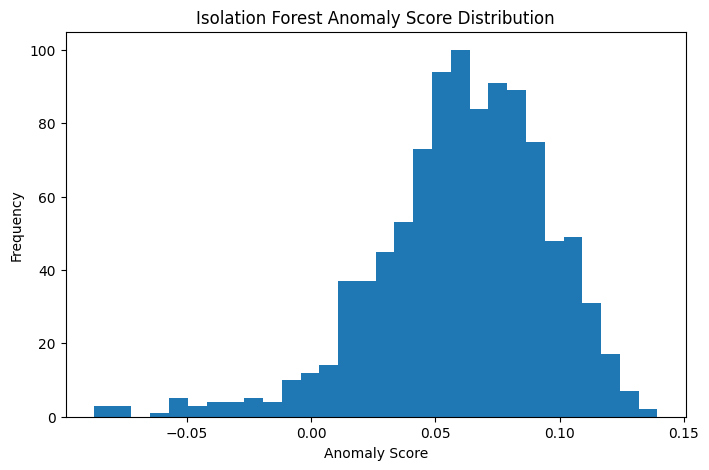

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(data['Anomaly_Score'], bins=30)
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()

Auto encoder model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam',loss='mse')

In [ ]:
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.0634 - val_loss: 1.0296
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9650 - val_loss: 0.9752
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9596 - val_loss: 0.9235
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8210 - val_loss: 0.8750
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8193 - val_loss: 0.8105
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7488 - val_loss: 0.7330
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6787 - val_loss: 0.6463
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6074 - val_loss: 0.5636
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5222 - val_loss: 0.4961
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4821 - val_loss: 0.4476
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4146 - val_loss: 0.4149
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3874 - val_l

In [ ]:
reconstructions = autoencoder.predict(X_scaled)
reconstruction_error = np.mean(
    np.square(X_scaled - reconstructions), axis=1
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
threshold = np.percentile(reconstruction_error, 95)

data['AE_Anomaly'] = reconstruction_error > threshold
data['AE_Anomaly'] = data['AE_Anomaly'].map({True: 1, False: 0})

In [ ]:
data['AE_Anomaly'].value_counts()

,count
AE_Anomaly,
0,950
1,50


An autoencoder is a neural network trained to reconstruct normal data patterns. Transactions with high reconstruction error are considered anomalous and flagged as potential fraud.

In [ ]:
# Assuming X is your feature data
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X)

# Predict anomalies: -1 means anomaly, 1 means normal
predictions = model.predict(X)

# Convert to 0 (normal) and 1 (anomaly)
IF_Anomaly = (predictions == -1).astype(int)

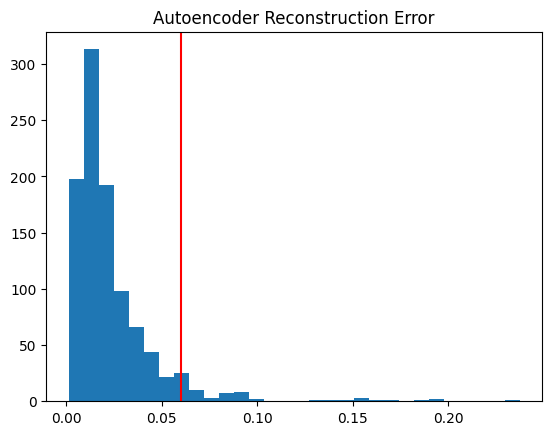

Number of anomalies detected: 50


In [ ]:
plt.hist(reconstruction_error, bins=30)
plt.axvline(threshold, color='red')
plt.title("Autoencoder Reconstruction Error")
plt.show()

print(f'Number of anomalies detected: {np.sum(IF_Anomaly)}')

In [ ]:
print(data.columns)

Index(['Transaction_ID', 'Transaction_Amount', 'Transaction_Volume',
       'Average_Transaction_Amount', 'Frequency_of_Transactions',
       'Time_Since_Last_Transaction', 'Day_of_Week', 'Time_of_Day', 'Age',
       'Gender', 'Income', 'Account_Type', 'IF_Anomaly', 'Anomaly_Score',
       'AE_Anomaly'],
      dtype='object')


Isolation Forest - Mean Score: 0.4620386064875742
Isolation Forest - Std Dev: 0.057827499519373694


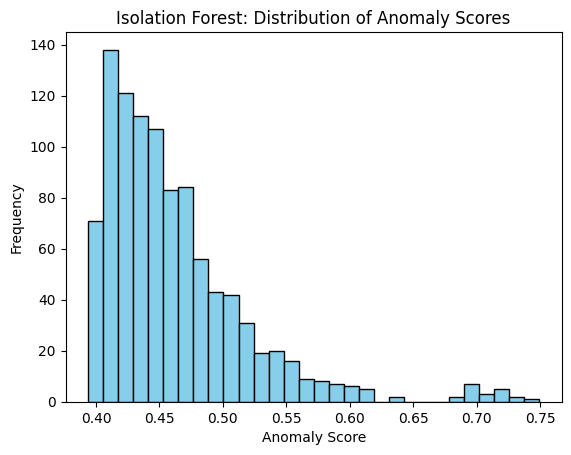

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

# Assuming X is your feature matrix
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X)

# Anomaly scores (the lower, the more normal; the higher, the more anomalous)
anomaly_scores_IF = -iso_model.score_samples(X)  # negate for intuitive "high = anomaly"

# Basic statistics
mean_IF = np.mean(anomaly_scores_IF)
std_IF = np.std(anomaly_scores_IF)
print("Isolation Forest - Mean Score:", mean_IF)
print("Isolation Forest - Std Dev:", std_IF)

# Histogram
plt.hist(anomaly_scores_IF, bins=30, color='skyblue', edgecolor='black')
plt.title('Isolation Forest: Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
anomaly_threshold_IF = mean_IF + 2 * std_IF
data['IF_Anomaly'] = anomaly_scores_IF > anomaly_threshold_IF
print("Number of anomalies detected:", data['IF_Anomaly'].sum())

Number of anomalies detected: 45


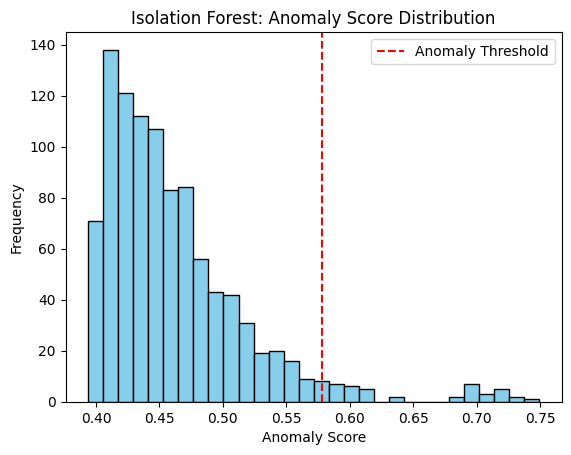

In [ ]:
plt.hist(anomaly_scores_IF, bins=30, color='skyblue', edgecolor='black')
plt.axvline(anomaly_threshold_IF, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Isolation Forest: Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Autoencoder - Mean Reconstruction Error: 719290.1187448907
Autoencoder - Std Dev: 374664.5575746605


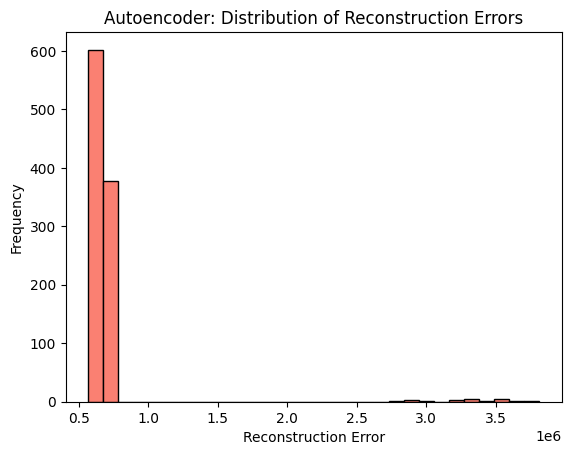

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Simple Autoencoder
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
autoencoder.fit(X, X, epochs=50, batch_size=32, shuffle=True, verbose=0)

# Reconstruction error
reconstructions = autoencoder.predict(X)
reconstruction_errors = np.mean(np.square(X - reconstructions), axis=1)

# Basic statistics
mean_AE = np.mean(reconstruction_errors)
std_AE = np.std(reconstruction_errors)
print("Autoencoder - Mean Reconstruction Error:", mean_AE)
print("Autoencoder - Std Dev:", std_AE)

# Histogram
plt.hist(reconstruction_errors, bins=30, color='salmon', edgecolor='black')
plt.title('Autoencoder: Distribution of Reconstruction Errors')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.show()

In [ ]:
anomaly_threshold_AE = mean_AE + 2 * std_AE
data['AE_Anomaly'] = reconstruction_errors > anomaly_threshold_AE
print("Number of anomalies detected by Autoencoder:", data['AE_Anomaly'].sum())

Number of anomalies detected by Autoencoder: 20


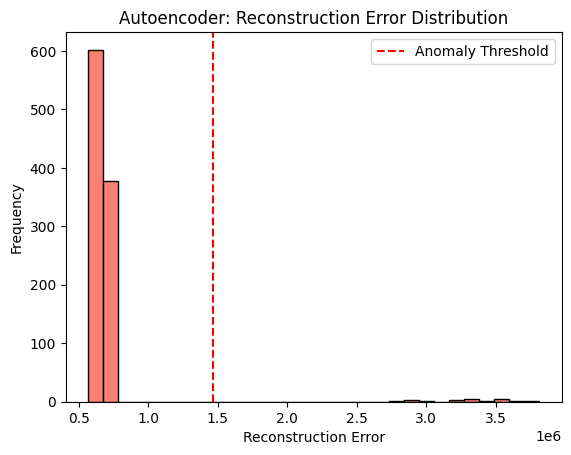

In [ ]:
plt.hist(reconstruction_errors, bins=30, color='salmon', edgecolor='black')
plt.axvline(anomaly_threshold_AE, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Autoencoder: Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()